<a href="https://colab.research.google.com/github/Ismot10/Disaster-Management-and-Early-Warning-System-App/blob/main/LSTM_for_FLOOD_management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELL 1 — Install & Import Libraries


# ==============================
# 📦 Install required libraries
# ==============================
!pip install pandas numpy matplotlib scikit-learn tensorflow --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
# CELL 2 — Upload Your Dataset

from google.colab import files
uploaded = files.upload()


Saving flood_dataset.csv to flood_dataset.csv


In [ ]:
# CELL 3 — Load & Inspect Data

# Load dataset
df = pd.read_csv("flood_dataset.csv")

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Remove rows where timestamp conversion failed
df = df.dropna(subset=['timestamp'])


# Sort by time (VERY IMPORTANT for LSTM)
df = df.sort_values('timestamp')

df.head()


,timestamp,water_level_cm,rain_intensity_percent,water_sensor_percent,flood_detected
0,2025-11-06 12:00:00,87.454012,18.513293,26.170568,No
1,2025-11-06 12:00:05,145.071431,54.190095,24.697880,No
2,2025-11-06 12:00:10,123.199394,87.294584,90.625458,No
3,2025-11-06 12:00:15,109.865848,73.222489,24.954620,No
4,2025-11-06 12:00:20,65.601864,80.656115,27.194973,No


In [ ]:
# CELL 4 — Select Features (NO flood_detected)

features = [
    'water_level_cm',
    'rain_intensity_percent',
    'water_sensor_percent'
]

data = df[features]
data.describe()


,water_level_cm,rain_intensity_percent,water_sensor_percent
count,1000.000000,1000.000000,1000.000000
mean,99.025655,50.701731,50.240573
std,29.213736,29.218989,29.067420
min,50.463202,0.321826,0.001163
25%,73.597327,24.107427,26.135098
50%,99.680738,51.873391,50.061392
75%,124.431959,76.046506,75.910353
max,149.971767,99.941373,99.782086


In [ ]:
# CELL 5 — Normalize Data


scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)


In [ ]:
# CELL 6 — Create Time-Series Sequences


SEQUENCE_LENGTH = 10   # past 10 readings

X = []
y = []

for i in range(SEQUENCE_LENGTH, len(scaled_data)):
    X.append(scaled_data[i-SEQUENCE_LENGTH:i])
    y.append(scaled_data[i][0])  # future water_level

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (990, 10, 3)
y shape: (990,)


In [ ]:
# CELL 7 — Train / Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [ ]:
# CELL 8 — Build LSTM Model


model  = Sequential([
    LSTM(
        32,
        input_shape=(X.shape[1], X.shape[2]),
        return_sequences=False,
        unroll=True,          # 🔥 REQUIRED for Flutter
        activation="tanh",
        recurrent_activation="sigmoid"
    ),
    Dense(1)
])


model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,641 (18.13 KB)

 Trainable params: 4,641 (18.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# CELL 9 — Train Model


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.1187 - val_loss: 0.0875
Epoch 2/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0916 - val_loss: 0.0859
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0875 - val_loss: 0.0840
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0878 - val_loss: 0.0860
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0867 - val_loss: 0.0851
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0854 - val_loss: 0.0842
Epoch 7/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0812 - val_loss: 0.0858
Epoch 8/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0898 - val_loss: 0.0854


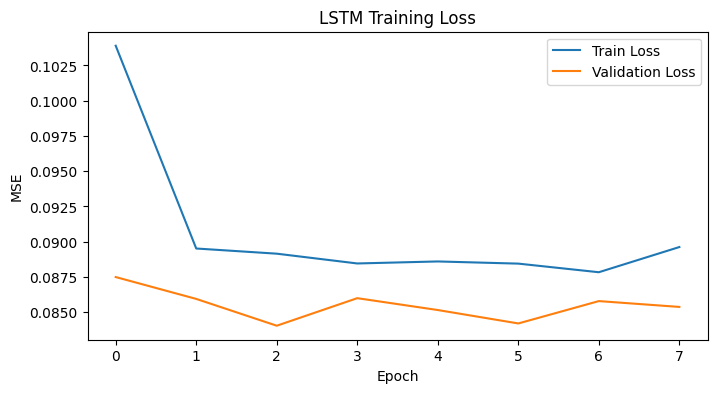

In [ ]:
# CELL 10 — Visualize Training



plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step


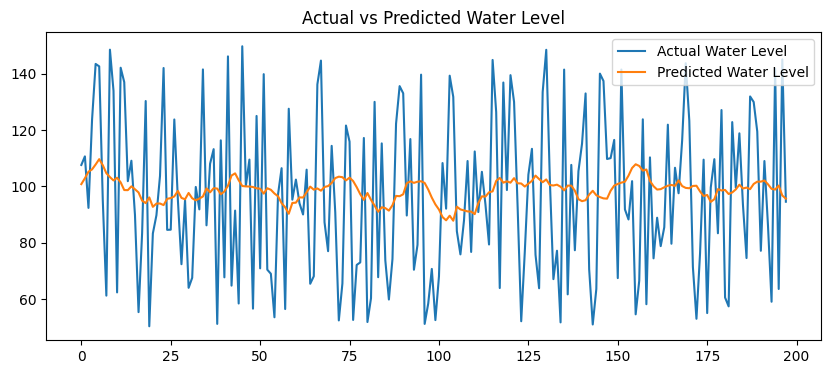

In [ ]:
# CELL 11 — Test Prediction


predictions = model.predict(X_test)

# Reverse scaling (only water level column)
water_scaler = MinMaxScaler()
water_scaler.min_ = scaler.min_[0:1]
water_scaler.scale_ = scaler.scale_[0:1]

predicted_water = water_scaler.inverse_transform(predictions.reshape(-1,1))
actual_water = water_scaler.inverse_transform(y_test.reshape(-1,1))

plt.figure(figsize=(10,4))
plt.plot(actual_water, label="Actual Water Level")
plt.plot(predicted_water, label="Predicted Water Level")
plt.legend()
plt.title("Actual vs Predicted Water Level")
plt.show()


In [ ]:
# CELL 12 — Model Evaluation Metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make prediction
predictions = model.predict(X_test)

# Reverse scaling
water_scaler = MinMaxScaler()
water_scaler.min_ = scaler.min_[0:1]
water_scaler.scale_ = scaler.scale_[0:1]

predicted_water = water_scaler.inverse_transform(predictions.reshape(-1,1))
actual_water = water_scaler.inverse_transform(y_test.reshape(-1,1))

# Metrics
mae = mean_absolute_error(actual_water, predicted_water)
mse = mean_squared_error(actual_water, predicted_water)
rmse = np.sqrt(mse)
r2 = r2_score(actual_water, predicted_water)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
MAE : 24.773345244692003
MSE : 832.1223388249822
RMSE: 28.8465307935804
R2 Score: -0.026836192524920977


In [ ]:
# CELL 12 — Save Model

model.save("flood_lstm_model.keras")
print("✅ Model saved successfully (Keras format)")



✅ Model saved successfully (Keras format)


In [ ]:
# CELL 13 — Load Saved Model



import tensorflow as tf

# Load the trained model
model = tf.keras.models.load_model("flood_lstm_model.keras")

print("✅ Model loaded successfully")


✅ Model loaded successfully


In [ ]:
# CELL 14 — Convert to TensorFlow Lite




# CELL 14 — Convert to PURE TensorFlow Lite (Flutter Compatible)

import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# ✅ ONLY built-in TFLite ops (NO Flex, NO Select TF Ops)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

# 🔥 FORCE removal of TensorList ops (CRITICAL)
converter._experimental_lower_tensor_list_ops = True
converter.experimental_enable_resource_variables = False

# Optional but safe
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert
tflite_model = converter.convert()

# Save model
with open("flood_lstm_model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ PURE TFLite model created (Flutter compatible)")



Saved artifact at '/tmp/tmp694w8e4p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139596226418576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139596226414736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139596226415120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139596226419344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139596226415888: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ PURE TFLite model created (Flutter compatible)


In [ ]:
# CELL 15 — Download TFLite Model


from google.colab import files
files.download("flood_lstm_model.tflite")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>